I have tried three Machine Learning models here RFC, SVM, LR
comppared these three models accuracy i am just worried about the fluctuation regarding SVM but actually it is giving high accuracy.


In [105]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch"]

X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)

# cross-validation (ONLY on training data)
scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", scores.mean()*100)

# train full model
model.fit(X, y)

# predict test
predictions = model.predict(X_test)

# output file
output = pd.DataFrame({
    'PassengerId': test_data.PassengerId,
    'Survived': predictions
})

# output.to_csv('submission_svm.csv', index=False)
# print("Submission saved!")

CV Accuracy: 79.91400414286612


In [106]:
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")


y = train_data["Survived"] #target
features = ["Pclass", "Sex", "SibSp", "Parch", "Age", "Fare", "Embarked"] #features
X = train_data[features].copy()
X_test = test_data[features].copy()

# Handle missing values
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

X_test["Age"] = X_test["Age"].fillna(X["Age"].median())
X_test["Fare"] = X_test["Fare"].fillna(X["Fare"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X["Embarked"].mode()[0])

# One-hot encoding
X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)

# align columns (VERY IMPORTANT)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# Scaling (CRITICAL for SVM)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Hyperparameter tuning
param_grid = {
    "C": [0.5, 1, 5, 10],
    "gamma": [0.01, 0.1, "scale"],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


# Validation accuracy
val_pred = best_model.predict(X_val)
acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy:", acc*100)

# Train final model
best_model.fit(X_scaled, y)

# Predict test data
predictions = best_model.predict(X_test_scaled)

# Submission file
output = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": predictions
})

# output.to_csv("svm_submission.csv", index=False)

# print("Submission file created successfully!")

Best Parameters: {'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}
Validation Accuracy: 81.56424581005587


In [107]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# load data
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# target
y = train_data["Survived"]

# features
features = ["Pclass", "Sex", "SibSp", "Parch"]

X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

# align columns (important safety step)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# model
model = LogisticRegression(max_iter=500)

# cross-validation (ONLY on training data)
scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", scores.mean()*100)

# train full model
model.fit(X, y)

# predict test
predictions = model.predict(X_test)

# output file
output = pd.DataFrame({
    'PassengerId': test_data.PassengerId,
    'Survived': predictions
})

# output.to_csv('submission_logreg.csv', index=False)
# print("Submission saved!")

CV Accuracy: 79.9083547799887


In [108]:
#check svm fluctuates or not

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import numpy as np

# model
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

# cross-validation (5 folds)
scores = cross_val_score(svm_model, X, y, cv=5)

# results
print("Fold Scores of all five folds:", scores*100)
print("Mean Accuracy:", np.mean(scores)*100)
print("Std Deviation (Fluctuation):", np.std(scores))

Fold Scores of all five folds: [81.00558659 80.33707865 80.8988764  79.21348315 80.8988764 ]
Mean Accuracy: 80.47078023978408
Std Deviation (Fluctuation): 0.006710026204970468


RF: 79.80038917833156
SVM: 80.47078023978408
LR: 79.9083547799887


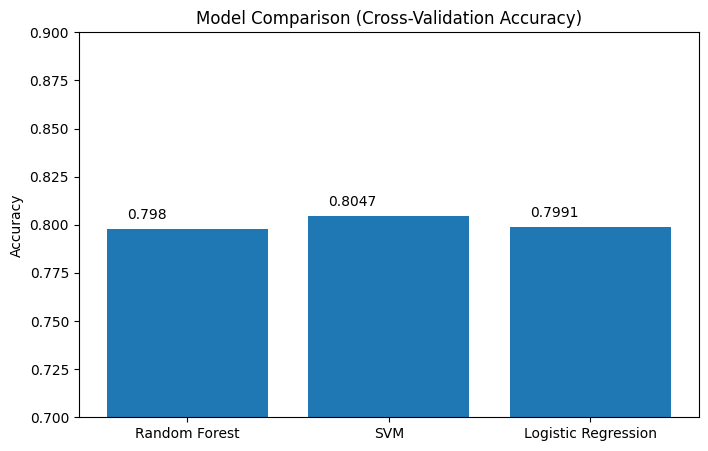

In [109]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# assume X, y already prepared (encoded + cleaned)

# models
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
svm = SVC(kernel='rbf', C=1, gamma='scale')
lr = LogisticRegression(max_iter=500)

# cross-validation scores
rf_score = cross_val_score(rf, X, y, cv=5).mean()
svm_score = cross_val_score(svm, X, y, cv=5).mean()
lr_score = cross_val_score(lr, X, y, cv=5).mean()

# store results
models = ["Random Forest", "SVM", "Logistic Regression"]
scores = [rf_score, svm_score, lr_score]

print("RF:", rf_score*100)
print("SVM:", svm_score*100)
print("LR:", lr_score*100)


plt.figure(figsize=(8,5))

bars = plt.bar(models, scores)

plt.title("Model Comparison (Cross-Validation Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)

# add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.005, round(yval, 4))

plt.show()